In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_sales = pd.read_csv("data/Warehouse_and_Retail_Sales.csv")
data_sales.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [2]:
data_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB


In [3]:
data_sales.describe()

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,307645.000000,307645.000000,307642.000000,307645.000000,307645.000000
mean,2018.438525,6.423862,7.024071,6.936465,25.294597
std,1.083061,3.461812,30.986238,30.237195,249.916798
min,2017.000000,1.000000,-6.490000,-38.490000,-7800.000000
25%,2017.000000,3.000000,0.000000,0.000000,0.000000
50%,2019.000000,7.000000,0.320000,0.000000,1.000000
75%,2019.000000,9.000000,3.267500,3.000000,5.000000
max,2020.000000,12.000000,2739.000000,1990.830000,18317.000000


In [4]:
data_sales.isnull().sum()


YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64

In [5]:
data_sales.duplicated().sum()

np.int64(0)

<Axes: xlabel='ITEM TYPE'>

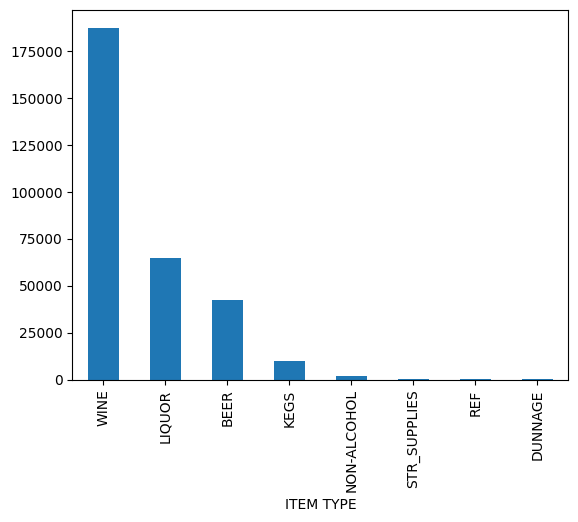

In [6]:
data_sales['ITEM TYPE'].value_counts().plot(kind='bar')

In [7]:
data_sales['MONTH'] = pd.to_datetime(data_sales['MONTH'])
data_sales['YEAR'] = pd.to_datetime(data_sales['YEAR'])

<Axes: xlabel='MONTH'>

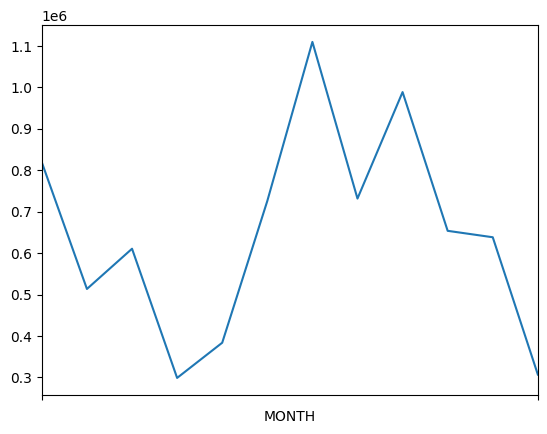

In [8]:
data_sales.groupby('MONTH')['WAREHOUSE SALES'].sum().plot()


<Axes: xlabel='YEAR'>

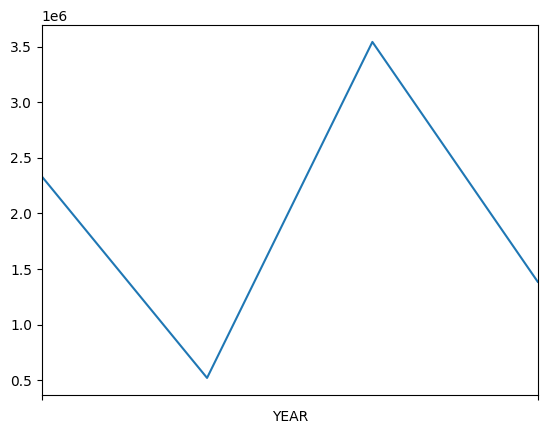

In [9]:
data_sales.groupby('YEAR')['WAREHOUSE SALES'].sum().plot()

C:\Users\tiara\AppData\Local\Temp\ipykernel_5964\1531752276.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_type.values, y=sales_by_type.index, palette="viridis")


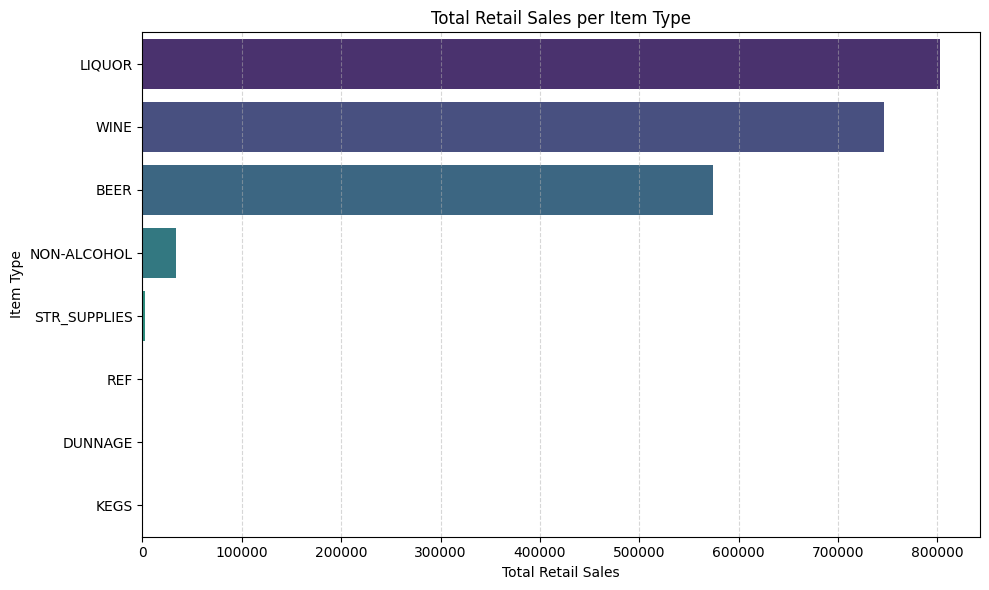

In [10]:
# Grouping dan menjumlahkan retail sales per item type
sales_by_type = data_sales.groupby("ITEM TYPE")["RETAIL SALES"].sum().sort_values(ascending=False)
# data_sales.groupby("ITEM TYPE")
# → Mengelompokkan baris data berdasarkan jenis produk

# ["RETAIL SALES"].sum()
# → Menjumlahkan total RETAIL SALES untuk tiap ITEM TYPE

# .sort_values(ascending=False)
# → Mengurutkan hasil dari yang tertinggi ke terendah



# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_type.values, y=sales_by_type.index, palette="viridis")
plt.title("Total Retail Sales per Item Type")
plt.xlabel("Total Retail Sales")
plt.ylabel("Item Type")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


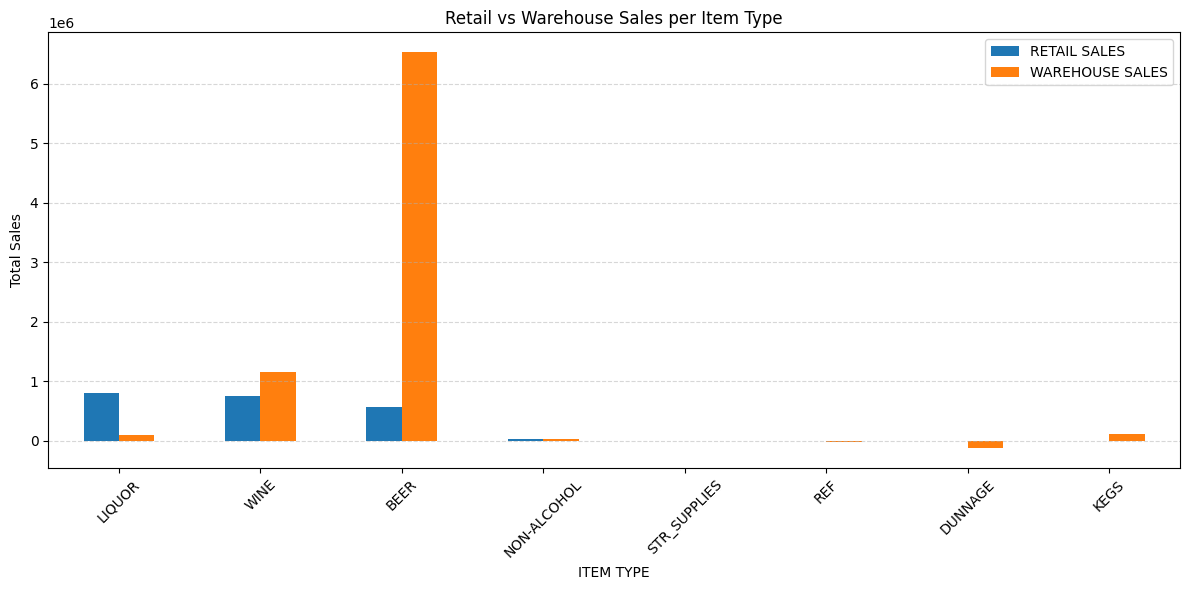

In [11]:
# Group by item type dan hitung total untuk dua kolom
sales_compare = data_sales.groupby("ITEM TYPE")[["RETAIL SALES", "WAREHOUSE SALES"]].sum().sort_values(by="RETAIL SALES", ascending=False)

# Plot
sales_compare.plot(kind="bar", figsize=(12,6))
plt.title("Retail vs Warehouse Sales per Item Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


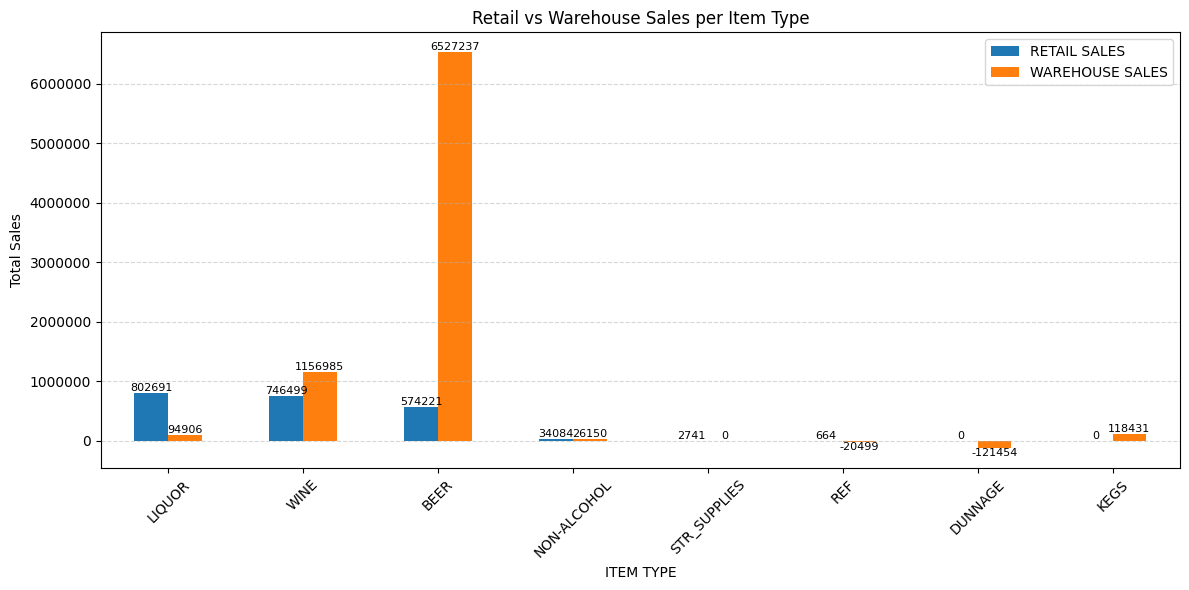

In [12]:
ax = sales_compare.plot(kind="bar", figsize=(12,6))
plt.title("Retail vs Warehouse Sales per Item Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ticklabel_format(style='plain', axis='y')  # ⬅️ Ini bagian penting


# Tambahkan label angka per bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8, label_type="edge")


plt.tight_layout()
plt.show()


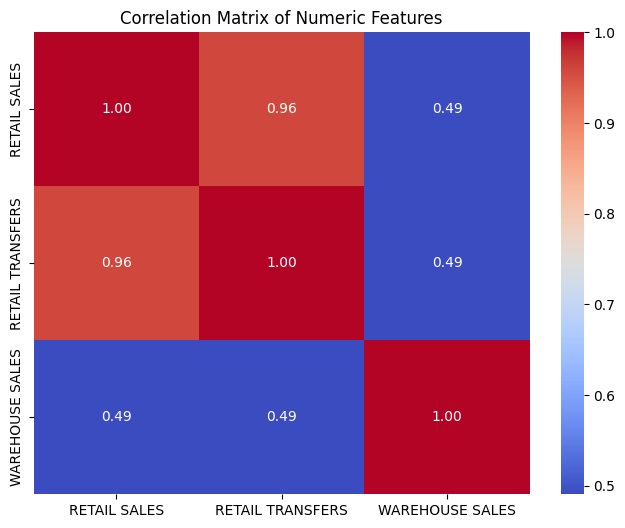

In [13]:
# Ambil kolom numerik
numeric_cols = data_sales.select_dtypes(include="number")

# Korelasi
corr = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()


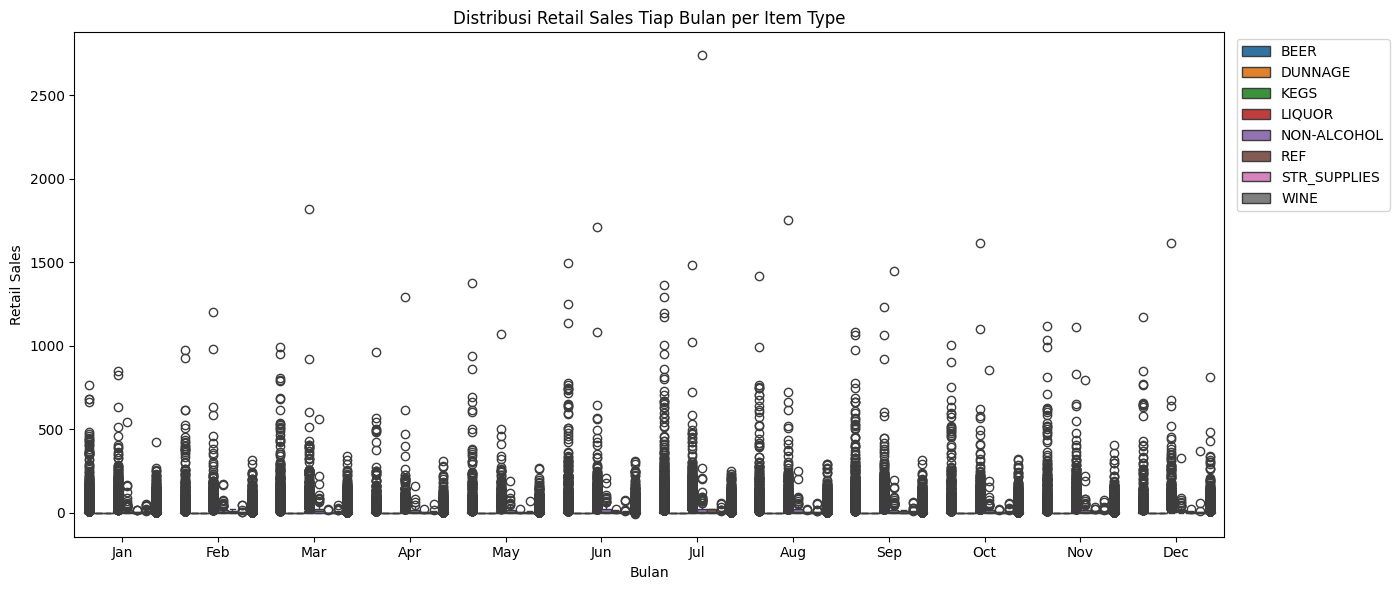

In [14]:
# Pastikan nilai penjualan adalah numerik (bukan string)
data_sales['RETAIL SALES'] = pd.to_numeric(data_sales['RETAIL SALES'], errors='coerce')

# Hapus baris yang memiliki nilai kosong di kolom penting
data_sales = data_sales.dropna(subset=['RETAIL SALES', 'ITEM TYPE'])

# Ubah ITEM TYPE jadi kategori (untuk efisiensi & visualisasi)
data_sales['ITEM TYPE'] = data_sales['ITEM TYPE'].astype('category')

# Gabungkan kolom tahun & bulan jadi satu kolom tanggal
data_sales['DATE'] = pd.to_datetime(data_sales[['YEAR', 'MONTH']].assign(DAY=1))

# Ekstrak nama bulan (Jan, Feb, dst)
data_sales['MONTH_NAME'] = data_sales['DATE'].dt.strftime('%b')

# Atur agar urutan bulan tidak acak
bulan_urut = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data_sales['MONTH_NAME'] = pd.Categorical(data_sales['MONTH_NAME'], categories=bulan_urut, ordered=True)


# Kode ini untuk menampilkan distribusi RETAIL SALES tiap bulan dan item type menggunakan boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(x="MONTH_NAME", y="RETAIL SALES", hue="ITEM TYPE", data=data_sales)

# Tambahan tampilan agar grafik lebih enak dibaca
plt.title("Distribusi Retail Sales Tiap Bulan per Item Type")
plt.xlabel("Bulan")
plt.ylabel("Retail Sales")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()


C:\Users\tiara\AppData\Local\Temp\ipykernel_5964\263428957.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = data_sales.groupby(["MONTH_NAME", "ITEM TYPE"])["RETAIL SALES"].mean().reset_index()


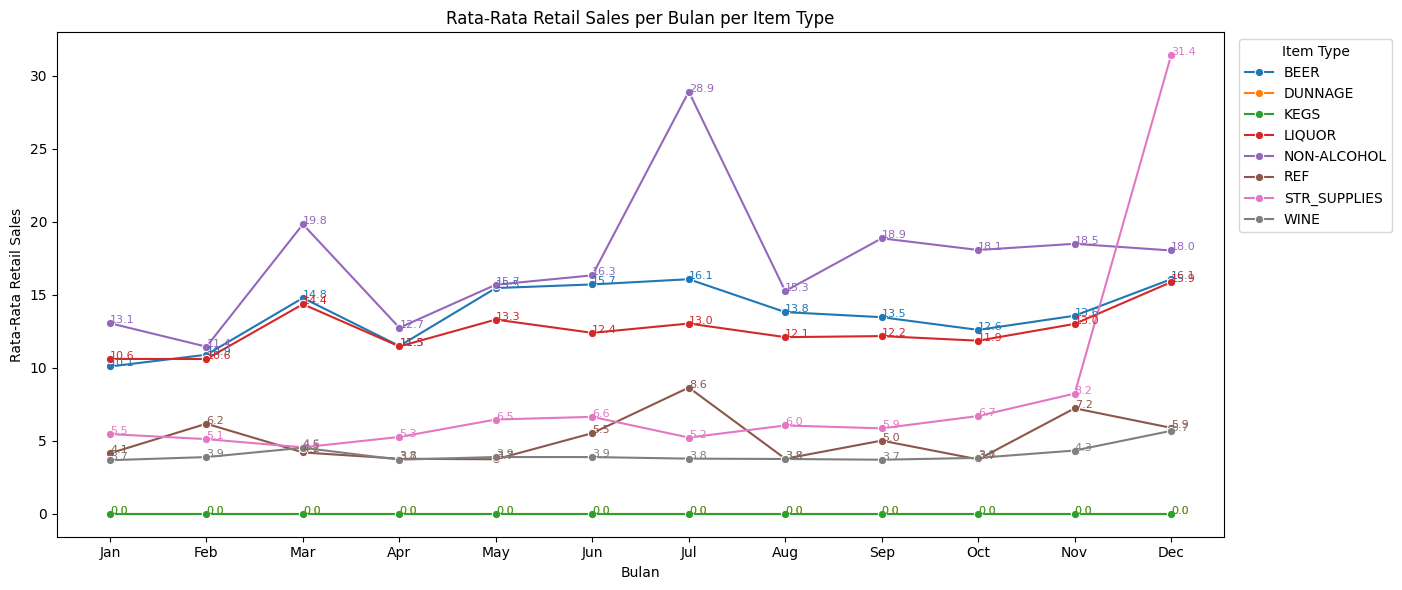

In [15]:
# Kode ini untuk menghitung rata-rata retail sales tiap bulan & item type
monthly_avg = data_sales.groupby(["MONTH_NAME", "ITEM TYPE"])["RETAIL SALES"].mean().reset_index()

# Pastikan nilai penjualan adalah numerik (bukan string)
data_sales['RETAIL SALES'] = pd.to_numeric(data_sales['RETAIL SALES'], errors='coerce')

# Hapus baris yang memiliki nilai kosong di kolom penting
data_sales = data_sales.dropna(subset=['RETAIL SALES', 'ITEM TYPE'])

# Ubah ITEM TYPE jadi kategori (untuk efisiensi & visualisasi)
data_sales['ITEM TYPE'] = data_sales['ITEM TYPE'].astype('category')

# Gabungkan kolom tahun & bulan jadi satu kolom tanggal
data_sales['DATE'] = pd.to_datetime(data_sales[['YEAR', 'MONTH']].assign(DAY=1))

# Ekstrak nama bulan (Jan, Feb, dst)
data_sales['MONTH_NAME'] = data_sales['DATE'].dt.strftime('%b')

# Atur agar urutan bulan tidak acak
bulan_urut = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data_sales['MONTH_NAME'] = pd.Categorical(data_sales['MONTH_NAME'], categories=bulan_urut, ordered=True)


# Kode ini untuk menampilkan distribusi RETAIL SALES tiap bulan dan item type menggunakan lineplot
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=monthly_avg, x="MONTH_NAME", y="RETAIL SALES", hue="ITEM TYPE", marker="o")

plt.title("Rata-Rata Retail Sales per Bulan per Item Type")
plt.xlabel("Bulan")
plt.ylabel("Rata-Rata Retail Sales")
plt.legend(title="Item Type", bbox_to_anchor=(1.15, 1))
# Tambah label data di atas tiap titik (opsional untuk eksplorasi lebih lanjut)
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x, y, f"{y:.1f}", fontsize=8, color=line.get_color())

plt.tight_layout()
plt.show()



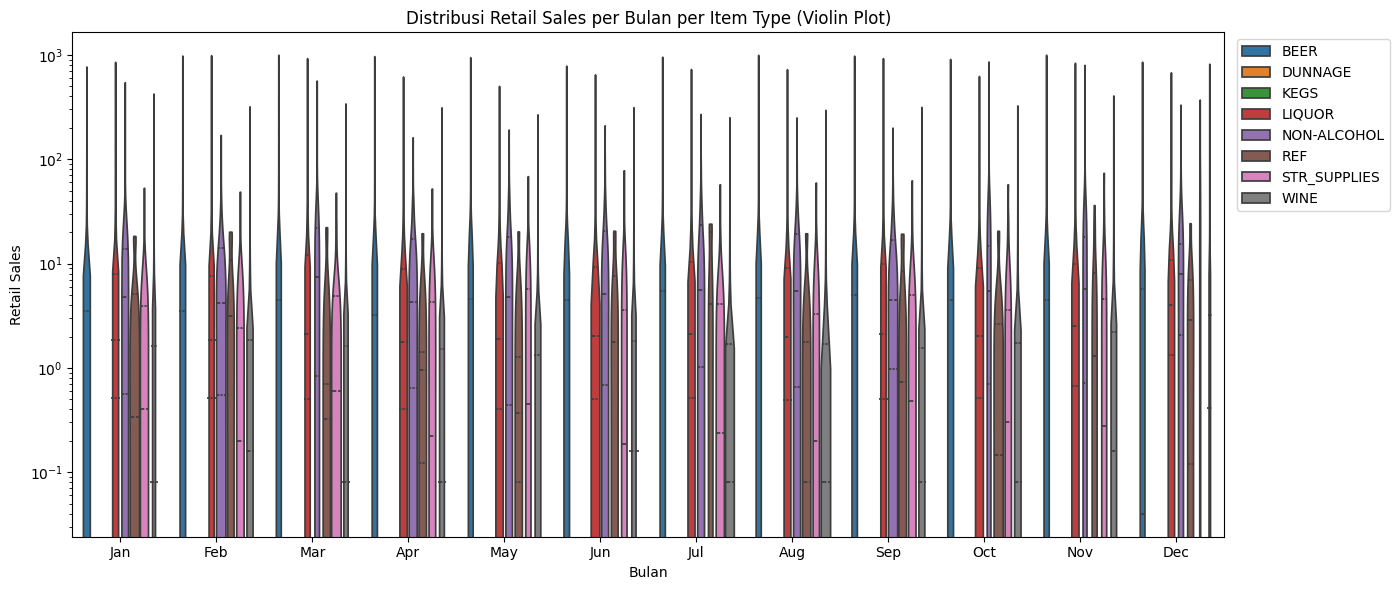

In [20]:
data_sales = data_sales[data_sales["RETAIL SALES"] < 1000]

plt.figure(figsize=(14, 6))
sns.violinplot(x="MONTH_NAME", y="RETAIL SALES", hue="ITEM TYPE", data=data_sales, cut=0, inner="quartile")
sns.set_palette("pastel")
plt.title("Distribusi Retail Sales per Bulan per Item Type (Violin Plot)")
plt.xlabel("Bulan")
plt.yscale("log")
plt.ylabel("Retail Sales")
plt.legend(bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()


C:\Users\tiara\AppData\Local\Temp\ipykernel_5964\1399449694.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(x="MONTH_NAME", y="RETAIL SALES", hue="ITEM TYPE", data=data_sales, ci="sd", dodge=True)


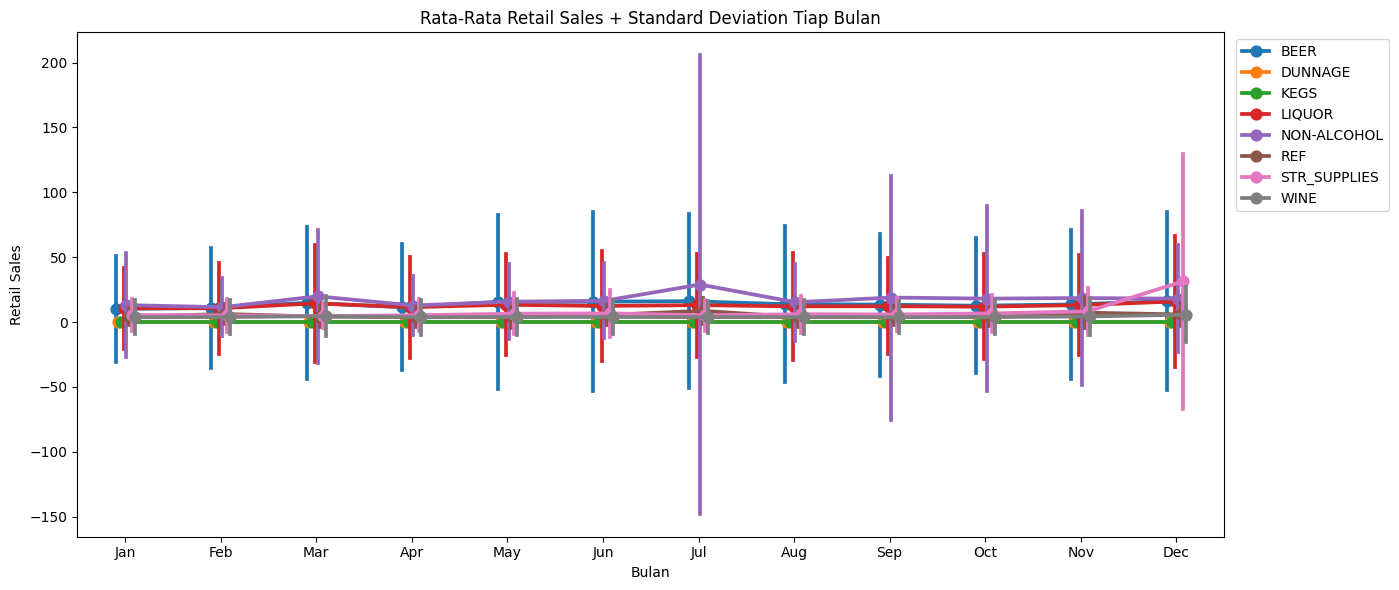

In [17]:
plt.figure(figsize=(14, 6))
sns.pointplot(x="MONTH_NAME", y="RETAIL SALES", hue="ITEM TYPE", data=data_sales, ci="sd", dodge=True)
plt.title("Rata-Rata Retail Sales + Standard Deviation Tiap Bulan")
plt.xlabel("Bulan")
plt.ylabel("Retail Sales")
plt.legend(bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()


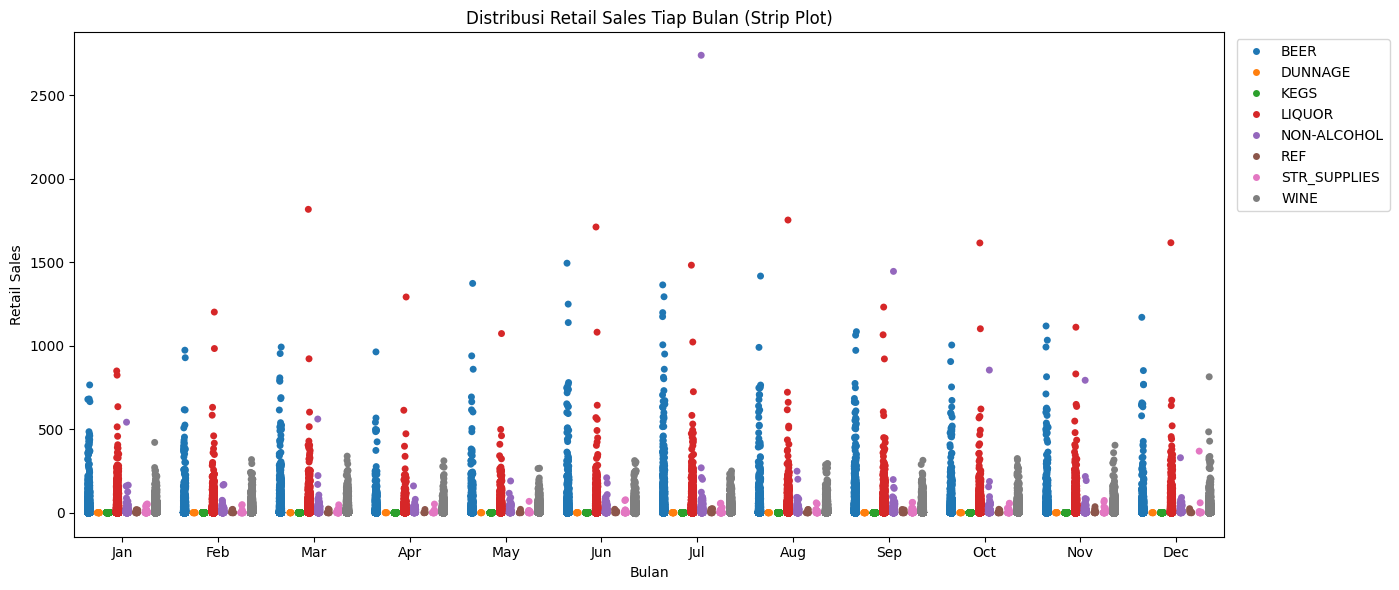

In [18]:
plt.figure(figsize=(14, 6))
sns.stripplot(x="MONTH_NAME", y="RETAIL SALES", hue="ITEM TYPE", data=data_sales, dodge=True, jitter=True)
plt.title("Distribusi Retail Sales Tiap Bulan (Strip Plot)")
plt.xlabel("Bulan")
plt.ylabel("Retail Sales")
plt.legend(bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()
